# Modelagem — Previsão de Resultado de Partidas (Vitória / Empate / Derrota)

Este notebook treina e compara diferentes algoritmos de classificação para prever
o resultado de uma partida internacional de futebol a partir das features
construídas em `src/features.py` (rating Elo, forma recente, confrontos diretos,
descanso, tipo de torneio).

## Estratégia de validação

A divisão treino/teste é **temporal**, não aleatória: treinamos com partidas até
2022 e testamos com partidas de **2023 em diante**. Um k-fold aleatório
"vazaria" informação do futuro para o passado (a forma recente de uma seleção em
2024 é calculada a partir de jogos que só fazem sentido cronologicamente depois
de 2022) e não reflete o uso real do modelo — prever jogos futuros a partir de
dados passados.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline

from src.data_prep import get_modeling_dataset
from src.modeling import prepare_X_y, time_based_split, get_models, run_all_models, TEST_START_YEAR

df = pd.read_csv("../data/processed/matches_features.csv", parse_dates=["date"])
modeling_df = get_modeling_dataset(df)
train_df, test_df = time_based_split(modeling_df, TEST_START_YEAR)

print(f"Amostra de modelagem (2000+): {len(modeling_df)} partidas")
print(f"Treino (até {TEST_START_YEAR-1}): {len(train_df)} partidas")
print(f"Teste ({TEST_START_YEAR}+): {len(test_df)} partidas")

X_train, y_train = prepare_X_y(train_df)
X_test, y_test = prepare_X_y(test_df)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.shape, X_test.shape


Amostra de modelagem (2000+): 25363 partidas
Treino (até 2022): 21745 partidas
Teste (2023+): 3618 partidas


((21745, 24), (3618, 24))

## Modelos avaliados

| Modelo | Por que foi incluído |
|---|---|
| **Baseline (classe majoritária)** | Referência mínima — qualquer modelo real precisa superar isso |
| **Regressão Logística** | Modelo linear interpretável, bom baseline "de verdade" |
| **Árvore de Decisão** | Captura interações não-lineares simples, fácil de interpretar |
| **Random Forest** | Ensemble robusto a overfitting, boa baseline não-linear |
| **Gradient Boosting (HistGB)** | Geralmente o mais competitivo em dados tabulares estruturados |

Todos os modelos (exceto o baseline) usam `class_weight="balanced"` para compensar
o desbalanceamento das classes (empates são ~23% das partidas, ver notebook de
EDA).


In [2]:
results = run_all_models(X_train, y_train, X_test, y_test)

summary = pd.DataFrame([
    {"Modelo": r["model_name"], "Acurácia": r["accuracy"], "F1-macro": r["f1_macro"]}
    for r in results
]).sort_values("F1-macro", ascending=False)
summary


Baseline (classe majoritaria)    | acc=0.473 | f1_macro=0.214


Regressao Logistica              | acc=0.580 | f1_macro=0.528


Arvore de Decisao                | acc=0.568 | f1_macro=0.526


Random Forest                    | acc=0.578 | f1_macro=0.523


Gradient Boosting (HistGB)       | acc=0.576 | f1_macro=0.532


,Modelo,Acurácia,F1-macro
4,Gradient Boosting (HistGB),0.575732,0.531915
1,Regressao Logistica,0.579878,0.528068
2,Arvore de Decisao,0.568270,0.526151
3,Random Forest,0.578496,0.522845
0,Baseline (classe majoritaria),0.472637,0.213964


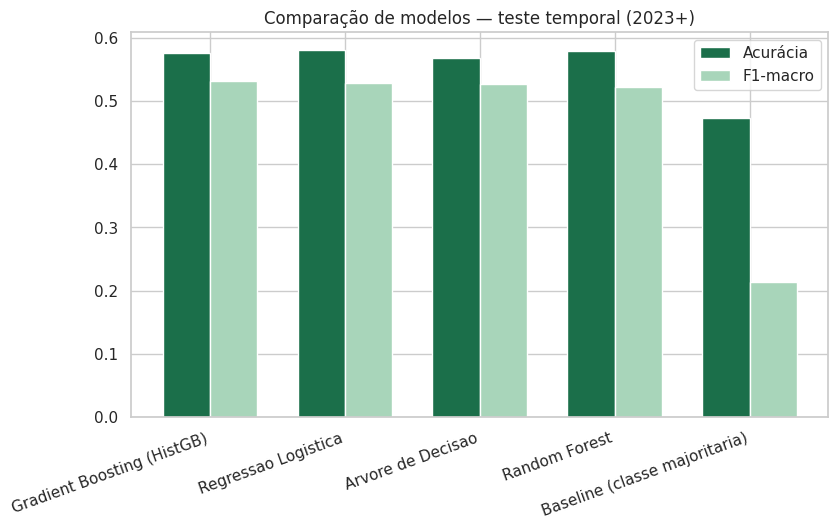

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary["Acurácia"], width, label="Acurácia", color="#1b6f4a")
ax.bar(x + width/2, summary["F1-macro"], width, label="F1-macro", color="#a8d5ba")
ax.set_xticks(x); ax.set_xticklabels(summary["Modelo"], rotation=20, ha="right")
ax.legend(); ax.set_title("Comparação de modelos — teste temporal (2023+)")
plt.show()


## Discussão dos resultados

Todos os modelos superam claramente o baseline (que prevê sempre "vitória do
mandante"): a acurácia sai de ~47% para ~57–58%, e o F1-macro sobe de ~0.21 para
~0.52–0.53 — um salto grande, já que o baseline simplesmente ignora as classes
minoritárias (empate e vitória do visitante).

Entre os modelos "de verdade", a diferença de desempenho é pequena (1 a 2 pontos
percentuais de acurácia). Isso é esperado: resultado de partida de futebol tem um
componente de aleatoriedade alto (lesões, arbitragem, um gol de pênalti contra),
e mesmo casas de apostas profissionais — que têm acesso a muito mais informação
(escalações, lesões, odds de mercado) — não passam muito de 55-60% de acurácia em
previsões de resultado. O Gradient Boosting teve o melhor F1-macro e foi escolhido
como modelo "de produção" usado no dashboard.


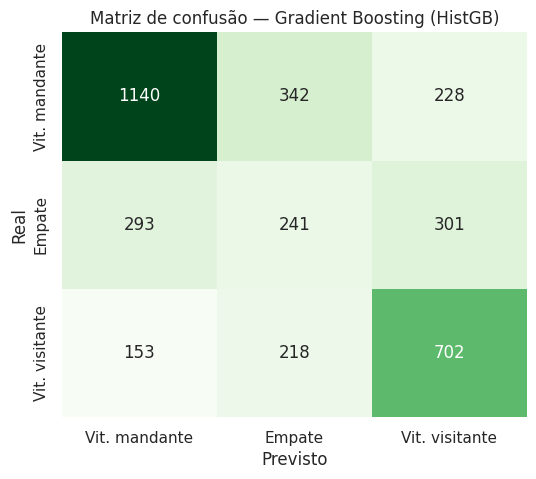

Melhor modelo: Gradient Boosting (HistGB)
  home_win   precision=0.72 recall=0.67 f1=0.69 (n=1710)
  draw       precision=0.30 recall=0.29 f1=0.29 (n=835)
  away_win   precision=0.57 recall=0.65 f1=0.61 (n=1073)


In [4]:
best = max(results, key=lambda r: r["f1_macro"])
cm = np.array(best["confusion_matrix"])
labels = ["Vit. mandante", "Empate", "Vit. visitante"]

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_title(f"Matriz de confusão — {best['model_name']}")
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
plt.show()

print(f"Melhor modelo: {best['model_name']}")
for classe, m in best["classification_report"].items():
    if classe in ["home_win","draw","away_win"]:
        print(f"  {classe:10s} precision={m['precision']:.2f} recall={m['recall']:.2f} f1={m['f1-score']:.2f} (n={int(m['support'])})")


**Empates são, de fato, a classe mais difícil** — recall bem mais baixo que as
outras duas classes na matriz de confusão acima, confirmando a hipótese
levantada na EDA. Isso é consistente com a natureza do problema: um empate
muitas vezes reflete equilíbrio momentâneo entre as equipes, não um padrão
estrutural fácil de capturar a partir de histórico passado.


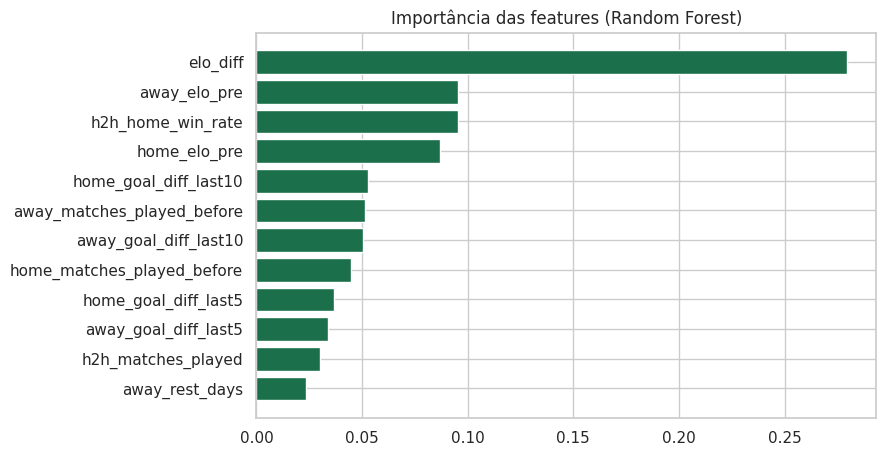

In [5]:
from sklearn.base import clone
rf = clone(get_models()["Random Forest"])
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(importances.index[::-1], importances.values[::-1], color="#1b6f4a")
ax.set_title("Importância das features (Random Forest)")
plt.show()


## Conclusão da modelagem

A **diferença de rating Elo** entre as seleções é, isoladamente, a feature mais
importante — confirma que o investimento em construir esse rating (em vez de
usar só nome do time/data) valeu a pena. O histórico de confrontos diretos
(`h2h_home_win_rate`) e os ratings absolutos de cada seleção também aparecem entre
as mais relevantes, enquanto features de "forma recente" (últimos 5/10 jogos)
têm peso menor — sugerindo que força estrutural de longo prazo prediz mais do que
oscilações recentes de resultado.

**Limitações:** o modelo não usa informações de escalação, lesões de jogadores-
chave, nem odds de mercado (que captam informação privilegiada de apostadores
profissionais) — extensões naturais para trabalhos futuros. O modelo final
("produção"), re-treinado com todo o histórico disponível, é o que alimenta o
dashboard interativo (`dashboard/app.py`), inclusive para prever partidas reais
ainda não disputadas da Copa do Mundo 2026.
